<a href="https://colab.research.google.com/github/HyoKwonJung/Emotional_AI/blob/ICES-2025/eeg_lstm_alpha(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
Data0904 = "/content/drive/MyDrive/AI/BCIs/EEG_Alpha/dataset/wsk_250904ex2dR.txt"
Data1028 = "/content/drive/MyDrive/AI/BCIs/EEG_Alpha/dataset/wsk_251028ex2dR.txt"
Data1031 = "/content/drive/MyDrive/AI/BCIs/EEG_Alpha/dataset/wsk_251031ex2dR.txt"
DataPath = Data0904

In [ ]:
# eeg_lstm_alpha.py
#   pip install numpy scipy pandas torch scikit-learn

import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from scipy.signal import get_window
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# ----------------------------------------
# 0) Data Augmentation Functions for EEG signals
# ----------------------------------------
def add_gaussian_noise(signal: np.ndarray, noise_level: float = 0.02, seed: Optional[int] = None) -> np.ndarray:
    """Add Gaussian noise to EEG signal"""
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    noise = rng.normal(0, noise_level * np.std(signal), signal.shape)
    return signal + noise

def scale_amplitude(signal: np.ndarray, scale_range: Tuple[float, float] = (0.8, 1.2), seed: Optional[int] = None) -> np.ndarray:
    """Randomly scale signal amplitude"""
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    scale = rng.uniform(scale_range[0], scale_range[1])
    return signal * scale

def time_shift(signal: np.ndarray, max_shift: int = 50, seed: Optional[int] = None) -> np.ndarray:
    """Circular shift in time domain"""
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    shift = rng.integers(-max_shift, max_shift + 1)
    return np.roll(signal, shift)

def apply_augmentation(signal: np.ndarray, augmentation_type: str = "random", seed: Optional[int] = None) -> np.ndarray:
    """
    Apply random augmentation to EEG signal
    augmentation_type: 'noise', 'scale', 'shift', 'random', or 'none'
    """
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    aug_types = ['noise', 'scale', 'shift', 'combine']

    if augmentation_type == 'none':
        return signal
    elif augmentation_type == 'random':
        aug_type = rng.choice(aug_types)
    else:
        aug_type = augmentation_type

    augmented = signal.copy()

    if aug_type == 'noise':
        return add_gaussian_noise(augmented, noise_level=0.02, seed=seed)
    elif aug_type == 'scale':
        return scale_amplitude(augmented, seed=seed)
    elif aug_type == 'shift':
        return time_shift(augmented, max_shift=50, seed=seed)
    elif aug_type == 'combine':
        # Apply multiple augmentations
        augmented = add_gaussian_noise(augmented, noise_level=0.015, seed=seed)
        augmented = scale_amplitude(augmented, seed=seed)
        augmented = time_shift(augmented, max_shift=30, seed=seed)
        return augmented

    return augmented

In [ ]:
# -----------------------------
# 1) Raw data & trial slicing
# -----------------------------
FS = 250
N_CH = 8
N_SAMPLES_USED = 2250  # 9s * 250 Hz
DELAY = 1.019    # dy in MATLAB code

# Event start sample indices (from the MATLAB script)
SMILE_STARTS = np.array([15482, 30762, 61383, 76640, 107295, 122503, 137816,
                         168376, 183682, 198953, 214257, 229552], dtype=int)  # 12 tries
ANGER_STARTS = np.array([23072, 38365, 53710, 84304, 114847,
                         176029, 206605, 221909], dtype=int)  # 8 tries

# Channels: MATLAB comments say 5=F8, 8=Fpz (1-indexed there). Here we'll use 0-index.
CH_F8 = 4   # MATLAB i=5 -> Python index 4
CH_FPZ = 7  # MATLAB i=8 -> Python index 7

@dataclass
class TrialConfig:
    start_samples: np.ndarray   # start indices per trial
    baseline_from: float        # seconds relative to start (start + from)
    baseline_to: float          # seconds relative to start (start + to)
    seg_from: float             # seconds relative to start
    seg_to: float               # seconds relative to start

# Matches the MATLAB slicing (baseline: +5s~+7s; analysis: +7s~+16s; both with delay applied)
TRIAL_CFG = TrialConfig(
    start_samples=None,  # set per class
    baseline_from=5.0 * DELAY,
    baseline_to=7.0 * DELAY,
    seg_from=7.0 * DELAY,
    seg_to=16.0 * DELAY,
)

def slice_trials_for_channel(
    FM: np.ndarray,
    channel_idx: int,
    start_samples: np.ndarray,
    cfg: TrialConfig,
    fs: int = FS,
    n_samples_used: int = N_SAMPLES_USED
) -> List[np.ndarray]:
    """
    FM: (n_channels, n_samples)
    Returns a list of baseline-corrected trial segments, each length n_samples_used (2250).
    """
    out = []
    for k, st in enumerate(start_samples):
        be = int(round(st + fs * cfg.seg_from))
        en = int(round(st + fs * cfg.seg_to))
        # MATLAB uses integer indices and then truncates to 2250
        sig = FM[channel_idx, be:en].astype(np.float64)

        b0 = int(round(st + fs * cfg.baseline_from))
        b1 = int(round(st + fs * cfg.baseline_to))
        baseline = FM[channel_idx, b0:b1].mean()

        sig_bc = sig - baseline
        # Ensure exactly 2250 samples like MATLAB: use first 2250
        sig_bc = sig_bc[:n_samples_used]
        if sig_bc.shape[0] < n_samples_used:
            # Pad if needed (rare)
            pad = np.zeros(n_samples_used - sig_bc.shape[0], dtype=np.float64)
            sig_bc = np.concatenate([sig_bc, pad], axis=0)
        out.append(sig_bc)
    return out


In [ ]:
# ---------------------------------------------
# 2) Alpha-power via STFT (1.5s window, 90% ov)
# ---------------------------------------------
def compute_alpha_power_stft(
    eeg_1ch: np.ndarray,
    fs: int = FS,
    window_size_sec: float = 1.5,
    overlap_percent: float = 90.0,
    alpha_band: Tuple[float, float] = (8.0, 13.0),
    use_db: bool = False
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns (alpha_power[1, n_windows], time_axis[n_windows]).
    Mirrors MATLAB round/steps to produce exactly 51 windows for 2250 samples.
    """
    n_samples = eeg_1ch.shape[0]
    win_len = int(round(window_size_sec * fs))  # 375
    ov_len = int(round(win_len * overlap_percent / 100.0))  # 338
    step = win_len - ov_len                                  # 37

    # Number of windows
    n_windows = int(math.floor((n_samples - win_len) / step) + 1)
    # Time axis at window centers
    time_axis = ((np.arange(n_windows) * step + win_len / 2) / fs).astype(np.float64)

    # Precompute window and frequency bins
    win = get_window("hann", win_len, fftbins=True).astype(np.float64)
    freq = np.arange(win_len, dtype=np.float64) * fs / win_len
    alpha_idx = np.where((freq >= alpha_band[0]) & (freq <= alpha_band[1]))[0]

    alpha_power = np.zeros((1, n_windows), dtype=np.float64)

    for i in range(n_windows):
        start = i * step
        end = start + win_len
        xw = eeg_1ch[start:end] * win
        fft_data = np.fft.fft(xw)
        pwr = np.abs(fft_data) ** 2
        alpha_power[0, i] = pwr[alpha_idx].mean() if alpha_idx.size > 0 else 0.0

    if use_db:
        alpha_power = 10.0 * np.log10(alpha_power + np.finfo(np.float64).eps)

    return alpha_power, time_axis

In [ ]:
# ----------------------------------------
# 4) PyTorch Dataset with Augmentation
# ----------------------------------------
class EEGSeqDataset(Dataset):
    def __init__(self, seqs: List[np.ndarray], labels: List[int],
                 apply_aug: bool = False, aug_prob: float = 0.5):
        self.seqs = seqs
        self.labels = labels
        self.apply_aug = apply_aug
        self.aug_prob = aug_prob

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        seq = self.seqs[idx].copy()

        # Apply augmentation with probability
        if self.apply_aug and random.random() < self.aug_prob:
            # Augment each feature dimension (Fpz and F8) separately
            for ch in range(seq.shape[1]):  # For each channel (2 channels)
                seq[:, ch] = apply_augmentation(seq[:, ch], augmentation_type='random')

        x = torch.from_numpy(seq).float()   # (51, 2) float32
        y = torch.tensor(self.labels[idx]).long()  # 0 or 1
        return x, y

In [ ]:
# ----------------------------------------
# 5) BiLSTM model
# ----------------------------------------
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_size=100,num_layers=1 ,num_classes=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # bi → *2

    def forward(self, x):
        # x: (B, T, F)
        out, _ = self.lstm(x)
        last = out[:, -1, :]  # OutputMode='last'
        last = self.dropout(last)  # Add dropout to prevent overfitting
        logits = self.fc(last)
        return logits

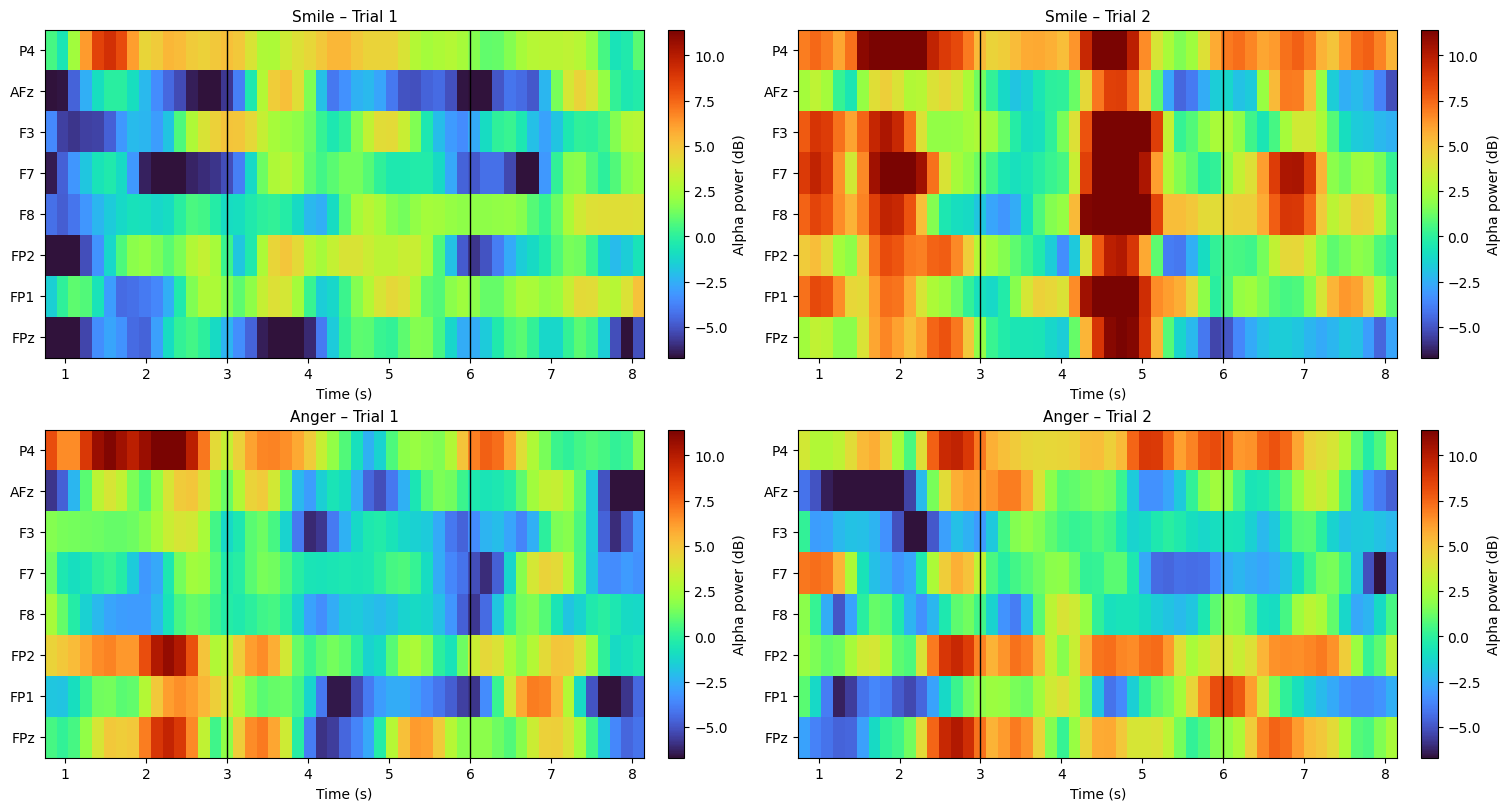

In [ ]:
# ============================================
# Alpha-power (8–13 Hz) STFT → dB → 2×2 heatmaps
# ============================================

import numpy as np, math
import matplotlib.pyplot as plt
from scipy.signal import get_window

# ---------- Config ----------
FS = 250  # sampling rate
WIN_SEC = 1.5
OVPCT   = 90.0
ALPHA   = (8.0, 13.0)
CMAP    = 'turbo'   # try 'turbo' for bright rainbow
VLINES  = [3.0, 6.0]  # seconds; set [] to remove
PICKS_SMILE = [0, 1]  # which Smile trials to show
PICKS_ANGER = [0, 1]  # which Anger trials to show

# If channel mapping constants aren't defined yet, define defaults (0-based)
CH_FPZ = 7; CH_FP1 = 6; CH_FP2 = 3; CH_F8 = 4
CH_F4  = 2; CH_F3  = 5; CH_AFZ = 1; CH_P4 = 0
# if 'CH_FPZ' not in globals():
#     CH_FPZ = 7; CH_FP1 = 6; CH_FP2 = 3; CH_F8 = 4
#     CH_F4  = 2; CH_F3  = 5; CH_AFZ = 1; CH_P4 = 0

CHS      = [CH_FPZ, CH_FP1, CH_FP2, CH_F8, CH_F4, CH_F3, CH_AFZ, CH_P4]  # top→bottom
CH_NAMES = ["FPz","FP1","FP2","F8","F7","F3","AFz","P4"]

# ---------- Upgraded alpha-power (Welch-style PSD) ----------
def compute_alpha_power_stft(
    eeg_1ch: np.ndarray,
    fs: int = FS,
    window_size_sec: float = WIN_SEC,
    overlap_percent: float = OVPCT,
    alpha_band=(8.0, 13.0),
    use_db: bool = True,
    return_psd: bool = False  # if True: µV^2/Hz mean PSD; else: µV^2 band power
):
    x = np.asarray(eeg_1ch, dtype=np.float64)
    n_samples = x.shape[0]

    win_len = int(round(window_size_sec * fs))          # 375
    ov_len  = int(round(win_len * overlap_percent/100)) # 338
    step    = win_len - ov_len                          # 37
    n_windows = int(math.floor((n_samples - win_len)/step) + 1)

    time_axis = ((np.arange(n_windows) * step + win_len/2) / fs).astype(np.float64)

    win = get_window("hann", win_len, fftbins=True).astype(np.float64)
    U   = np.sum(win**2)  # window power for PSD scaling

    freq = np.fft.rfftfreq(win_len, d=1.0/fs)           # one-sided
    df   = freq[1] - freq[0] if len(freq) > 1 else fs/win_len
    mask = (freq >= alpha_band[0]) & (freq <= alpha_band[1])

    out = np.zeros((1, n_windows), dtype=np.float64)
    eps = np.finfo(np.float64).eps

    for i in range(n_windows):
        s = i*step; e = s + win_len
        seg = x[s:e] - np.mean(x[s:e])                  # simple detrend
        Xw  = np.fft.rfft(seg * win)
        psd = (np.abs(Xw)**2) / (fs * U)                # µV^2/Hz

        if return_psd:
            val = psd[mask].mean() if mask.any() else 0.0          # µV^2/Hz
        else:
            val = (psd[mask].sum() * df) if mask.any() else 0.0    # µV^2 band power
        out[0, i] = val

    if use_db:
        out = 10.0 * np.log10(out + eps)                # dB of power

    return out, time_axis

# ---------- Build (channels × 51) alpha-power (dB) for one trial ----------
def alpha_matrix_for_trial(FM, channel_indices, trial_index, starts):
    mats = []
    T = None
    for ch in channel_indices:
        segs = slice_trials_for_channel(FM, ch, starts, TRIAL_CFG)  # expects 9s segments
        sig  = segs[trial_index]
        ap_db, t = compute_alpha_power_stft(sig, fs=FS, window_size_sec=WIN_SEC,
                                            overlap_percent=OVPCT, alpha_band=ALPHA,
                                            use_db=True, return_psd=False)
        mats.append(ap_db.squeeze(0))  # (51,)
        if T is None: T = t
    return np.stack(mats, axis=0), T    # (C × 51), (51,)

# ---------- Pretty heatmap (expects dB) ----------
def plot_heatmap_db(ax, data_db, t, ch_names, title="", vmin=None, vmax=None, cmap=CMAP):
    im = ax.imshow(data_db, aspect='auto', origin='lower',
                   extent=[t[0], t[-1], 0.5, data_db.shape[0]+0.5],
                   vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_yticks(np.arange(1, data_db.shape[0]+1))
    ax.set_yticklabels(ch_names)
    ax.set_xlabel("Time (s)")
    ax.set_title(title, fontsize=11)
    for ts in VLINES:
        ax.axvline(ts, color='k', lw=1)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Alpha power (dB)")

# ============================================
# Load raw matrix FM (channels × samples)
# ============================================
raw = np.loadtxt(DataPath)
FM = raw.T if raw.shape[0] > raw.shape[1] else raw
assert 'FM' in globals(), "Define FM = (n_channels × n_samples) raw EEG before running."

# Build four panels (Smile×2, Anger×2)
M1, t = alpha_matrix_for_trial(FM, CHS, trial_index=PICKS_SMILE[0], starts=SMILE_STARTS)
M2, _ = alpha_matrix_for_trial(FM, CHS, trial_index=PICKS_SMILE[1], starts=SMILE_STARTS)
M3, _ = alpha_matrix_for_trial(FM, CHS, trial_index=PICKS_ANGER[0], starts=ANGER_STARTS)
M4, _ = alpha_matrix_for_trial(FM, CHS, trial_index=PICKS_ANGER[1], starts=ANGER_STARTS)

# Shared color scale from all dB values (robust percentiles)
all_db = np.concatenate([M1.ravel(), M2.ravel(), M3.ravel(), M4.ravel()])
vmin, vmax = np.percentile(all_db, [2, 98])  # tweak to [5,95] for more contrast

# Plot 2×2
fig, axes = plt.subplots(2, 2, figsize=(15, 8), constrained_layout=True)
plot_heatmap_db(axes[0,0], M1, t, CH_NAMES, "Smile – Trial 1", vmin=vmin, vmax=vmax)
plot_heatmap_db(axes[0,1], M2, t, CH_NAMES, "Smile – Trial 2", vmin=vmin, vmax=vmax)
plot_heatmap_db(axes[1,0], M3, t, CH_NAMES, "Anger – Trial 1", vmin=vmin, vmax=vmax)
plot_heatmap_db(axes[1,1], M4, t, CH_NAMES, "Anger – Trial 2", vmin=vmin, vmax=vmax)
plt.show()


In [ ]:
# ----------------------------------------
# 6) Utility: split like MATLAB dividerand
# ----------------------------------------
def split_indices(n_items: int, train_ratio: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    idx = np.arange(n_items)
    rng.shuffle(idx)
    n_train = int(round(n_items * train_ratio))
    train_idx = np.sort(idx[:n_train])
    test_idx = np.sort(idx[n_train:])
    return train_idx, test_idx

In [ ]:
# ----------------------------------------
# 7) k-Fold Cross-Validation for small datasets
# ----------------------------------------
from sklearn.model_selection import StratifiedKFold
import copy

def cross_validation_train(
    txt_path: str = DataPath,
    label_path: Optional[str] = None,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    seed: int = 1234,
    n_splits: int = 3,
    epochs: int = 30
):
    """
    Train using k-fold cross-validation for statistically meaningful results
    with a tiny dataset.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Prepare data
    raw = np.loadtxt(txt_path)
    FM = raw.T if raw.shape[0] > raw.shape[1] else raw

    # Build trials
    smiles_f8 = slice_trials_for_channel(FM, CH_F8, SMILE_STARTS, TRIAL_CFG)
    smiles_fpz = slice_trials_for_channel(FM, CH_FPZ, SMILE_STARTS, TRIAL_CFG)
    angers_f8 = slice_trials_for_channel(FM, CH_F8, ANGER_STARTS, TRIAL_CFG)
    angers_fpz = slice_trials_for_channel(FM, CH_FPZ, ANGER_STARTS, TRIAL_CFG)

    FpzSignals = smiles_fpz + angers_fpz
    F8Signals = smiles_f8 + angers_f8
    labels = np.array((["S"] * len(smiles_fpz)) + (["A"] * len(angers_fpz)))

    # Convert to sequences
    def features_2x51(fpz_sig, f8_sig):
        ap_fpz, _ = compute_alpha_power_stft(fpz_sig)
        ap_f8, _ = compute_alpha_power_stft(f8_sig)
        return np.vstack([ap_fpz, ap_f8]).T.astype(np.float32)

    X_seq = [features_2x51(FpzSignals[i], F8Signals[i]) for i in range(len(FpzSignals))]
    y = np.array([0 if l == "A" else 1 for l in labels])

    print(f"[INFO] Total samples: {len(X_seq)} (12 Smile + 8 Anger)")
    print(f"[INFO] Using {n_splits}-fold cross-validation")

    # k-fold CV
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_seq, y), 1):
        print(f"\n{'='*50}")
        print(f"Fold {fold}/{n_splits}")
        print(f"{'='*50}")

        X_train = [X_seq[i] for i in train_idx]
        y_train = [y[i] for i in train_idx]
        X_val = [X_seq[i] for i in val_idx]
        y_val = [y[i] for i in val_idx]

        print(f"Train: {len(X_train)} | Val: {len(X_val)}")

        train_ds = EEGSeqDataset(X_train, y_train, apply_aug=True, aug_prob=0.7)
        val_ds = EEGSeqDataset(X_val, y_val, apply_aug=False, aug_prob=0.0)

        train_loader = DataLoader(train_ds, batch_size=100, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=100, shuffle=False)

        model = BiLSTMClassifier(input_dim=2, hidden_size=200, num_classes=2, dropout=0.3).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

        # Train
        for epoch in range(1, epochs + 1):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        # Validate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.numel()

        fold_acc = 100.0 * correct / total if total else 0.0
        fold_accuracies.append(fold_acc)
        print(f"Fold {fold} validation accuracy: {fold_acc:.2f}%")

    # Summary
    print(f"\n{'='*50}")
    print(f"CROSS-VALIDATION RESULTS")
    print(f"{'='*50}")
    print(f"Individual fold accuracies: {[f'{acc:.2f}%' for acc in fold_accuracies]}")
    print(f"Mean accuracy: {np.mean(fold_accuracies):.2f}%")
    print(f"Std deviation: {np.std(fold_accuracies):.2f}%")

cross_validation_train(n_splits=3, epochs=100)


[INFO] Total samples: 20 (12 Smile + 8 Anger)
[INFO] Using 3-fold cross-validation

Fold 1/3
Train: 13 | Val: 7
Fold 1 validation accuracy: 100.00%

Fold 2/3
Train: 13 | Val: 7
Fold 2 validation accuracy: 85.71%

Fold 3/3
Train: 14 | Val: 6
Fold 3 validation accuracy: 100.00%

CROSS-VALIDATION RESULTS
Individual fold accuracies: ['100.00%', '85.71%', '100.00%']
Mean accuracy: 95.24%
Std deviation: 6.73%


## 데이터 증강 예시

데이터 증강 기법:
- **Gaussian Noise**: 가우시안 노이즈 추가 (2% 신호 표준편차)
- **Amplitude Scaling**: 진폭 0.8~1.2배 랜덤 스케일링
- **Time Shift**: 최대 50 샘플 순환 시프트
- **Combination**: 여러 기법 동시 적용

각 배치마다 70% 확률로 증강이 적용됩니다.
